In [1]:
from src.inner_product import InnerProductExperiment, InnerProductExperimentMixed, InnerProductExperimentFMA
from src.core.plotter import plot_error_vs_size
import matplotlib.pyplot as plt
import numpy as np

# Setup experiment parameters
dtype_list = [np.float32, np.float64]
sizes = [int(1.5 ** i) for i in range(2, 22)]  # e.g., 16 to 1024
repeats = 100

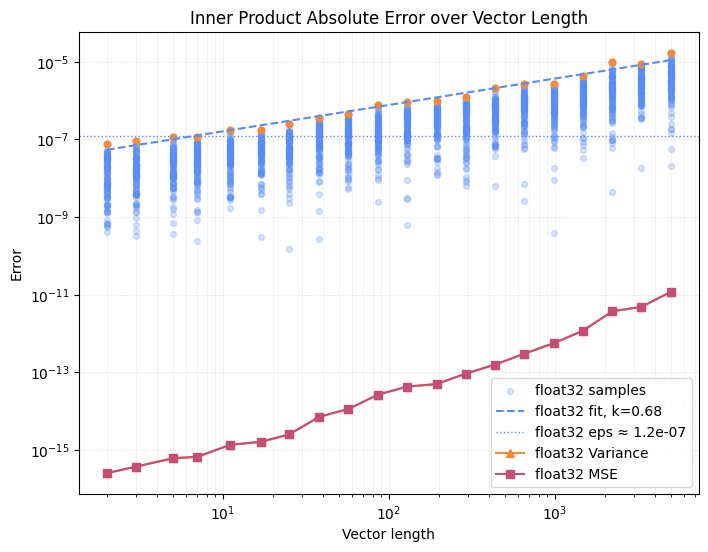

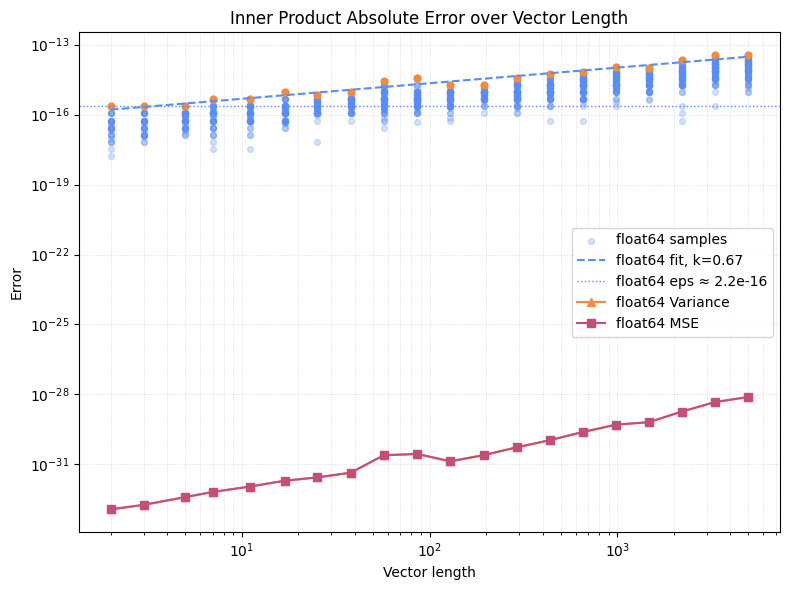

In [3]:
value_range = (-1, 1)

# Run experiment
exp = InnerProductExperiment(dtype_list, sizes, repeats, value_range)
exp.run()



for dtype in dtype_list:
    fig, ax = plt.subplots(figsize=(8, 6))
    error_matrix = np.array(exp.results[dtype])  # shape: [repeats, len(sizes)]
    plot_error_vs_size(
        sizes=sizes,
        error_matrix=error_matrix,
        dtype=dtype,
        label=dtype.__name__,
        ax=ax
    )
    var_matrix = np.var(error_matrix, axis=0)
    mse_matrix = np.mean((error_matrix - np.mean(error_matrix, axis=0))**2, axis=0)
    ax.plot(sizes, var_matrix, label=f"{dtype.__name__} Variance", marker='^')
    ax.plot(sizes, mse_matrix, label=f"{dtype.__name__} MSE", marker='s')
    ax.set_title("Inner Product Absolute Error over Vector Length")
    ax.legend()
plt.tight_layout()
plt.show()

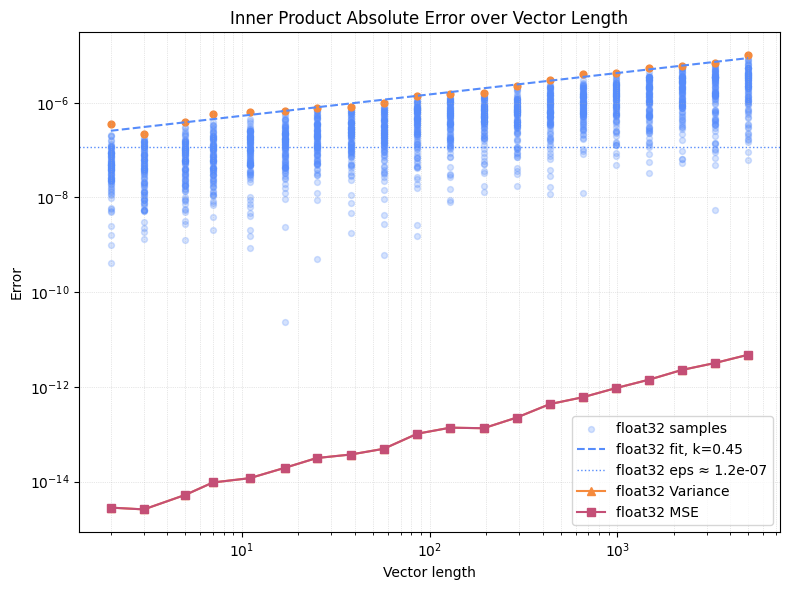

In [4]:

value_range = (-1, 1)
dtype = np.float32
exp = InnerProductExperimentMixed([dtype], sizes, repeats)
exp.run()

fig, ax = plt.subplots(figsize=(8, 6))
error_matrix = np.array(exp.results[dtype])  # shape: [repeats, len(sizes)]
plot_error_vs_size(
    sizes=sizes,
    error_matrix=error_matrix,
    dtype=dtype,
    label=dtype.__name__,
    ax=ax
)
var_matrix = np.var(error_matrix, axis=0)
mse_matrix = np.mean((error_matrix - np.mean(error_matrix, axis=0)) ** 2, axis=0)
ax.loglog(sizes, var_matrix, label=f"{dtype.__name__} Variance", marker='^')
ax.loglog(sizes, mse_matrix, label=f"{dtype.__name__} MSE", marker='s')
ax.set_title("Inner Product Absolute Error over Vector Length")
ax.legend()
plt.tight_layout()
plt.show()


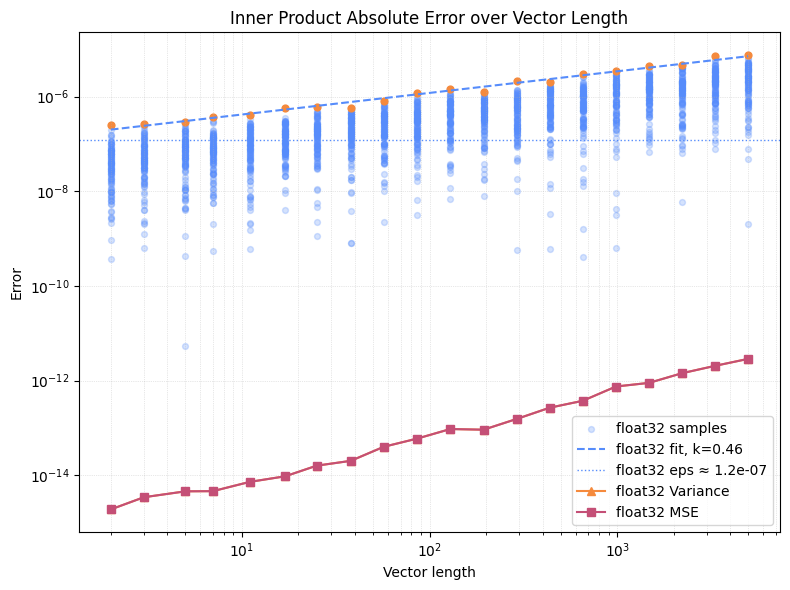

In [5]:

value_range = (-1, 1)
dtype = np.float32
exp = InnerProductExperimentFMA([dtype], sizes, repeats)
exp.run()

fig, ax = plt.subplots(figsize=(8, 6))
error_matrix = np.array(exp.results[dtype])  # shape: [repeats, len(sizes)]
plot_error_vs_size(
    sizes=sizes,
    error_matrix=error_matrix,
    dtype=dtype,
    label=dtype.__name__,
    ax=ax
)
var_matrix = np.var(error_matrix, axis=0)
mse_matrix = np.mean((error_matrix - np.mean(error_matrix, axis=0)) ** 2, axis=0)
ax.loglog(sizes, var_matrix, label=f"{dtype.__name__} Variance", marker='^')
ax.loglog(sizes, mse_matrix, label=f"{dtype.__name__} MSE", marker='s')
ax.set_title("Inner Product Absolute Error over Vector Length")
ax.legend()
plt.tight_layout()
plt.show()


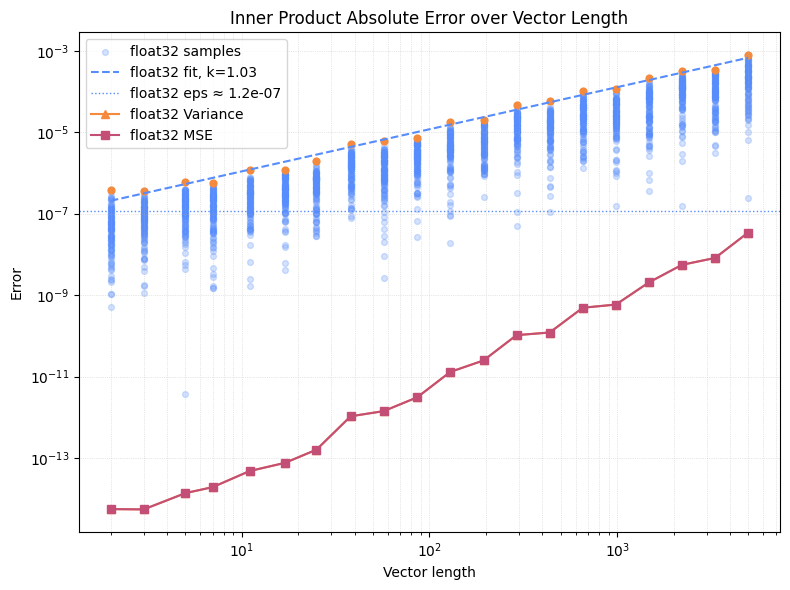

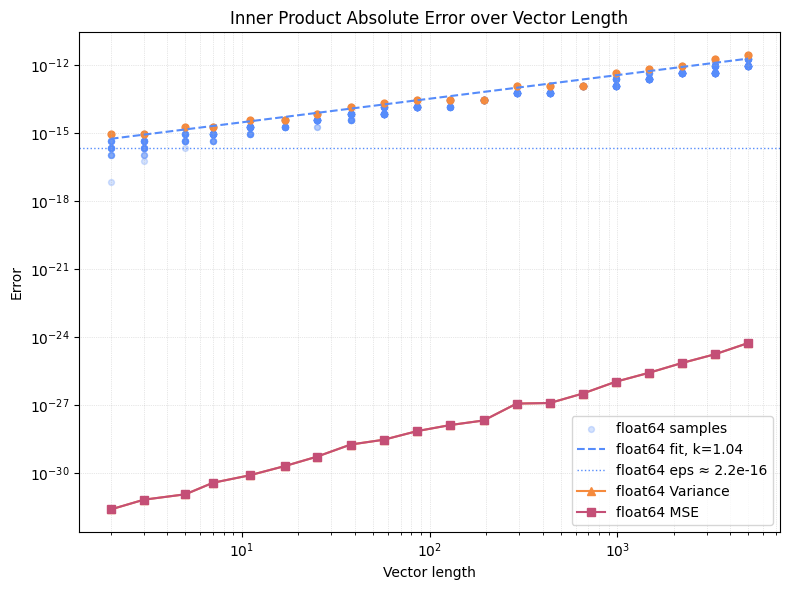

In [6]:
value_range = (0, 2)

# Run experiment
exp = InnerProductExperiment(dtype_list, sizes, repeats, value_range)
exp.run()



for dtype in dtype_list:
    fig, ax = plt.subplots(figsize=(8, 6))
    error_matrix = np.array(exp.results[dtype])  # shape: [repeats, len(sizes)]
    plot_error_vs_size(
        sizes=sizes,
        error_matrix=error_matrix,
        dtype=dtype,
        label=dtype.__name__,
        ax=ax
    )
    var_matrix = np.var(error_matrix, axis=0)
    mse_matrix = np.mean((error_matrix - np.mean(error_matrix, axis=0))**2, axis=0)
    ax.loglog(sizes, var_matrix, label=f"{dtype.__name__} Variance", marker='^')
    ax.loglog(sizes, mse_matrix, label=f"{dtype.__name__} MSE", marker='s')
    ax.set_title("Inner Product Absolute Error over Vector Length")
    ax.legend()
    plt.tight_layout()
    plt.show()

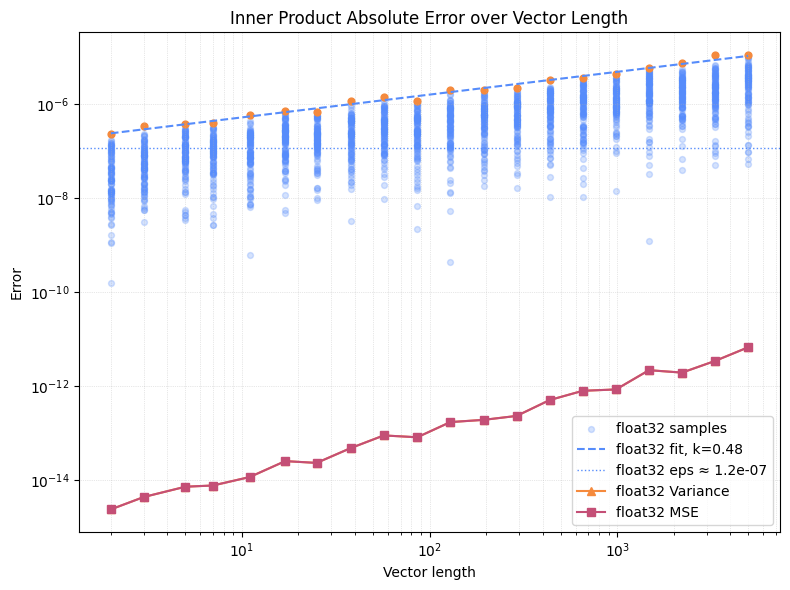

In [7]:

value_range = (0, 2)
dtype = np.float32
exp = InnerProductExperimentMixed([dtype], sizes, repeats)
exp.run()

fig, ax = plt.subplots(figsize=(8, 6))
error_matrix = np.array(exp.results[dtype])  # shape: [repeats, len(sizes)]
plot_error_vs_size(
    sizes=sizes,
    error_matrix=error_matrix,
    dtype=dtype,
    label=dtype.__name__,
    ax=ax
)
var_matrix = np.var(error_matrix, axis=0)
mse_matrix = np.mean((error_matrix - np.mean(error_matrix, axis=0)) ** 2, axis=0)
ax.loglog(sizes, var_matrix, label=f"{dtype.__name__} Variance", marker='^')
ax.loglog(sizes, mse_matrix, label=f"{dtype.__name__} MSE", marker='s')
ax.set_title("Inner Product Absolute Error over Vector Length")
ax.legend()
plt.tight_layout()
plt.show()


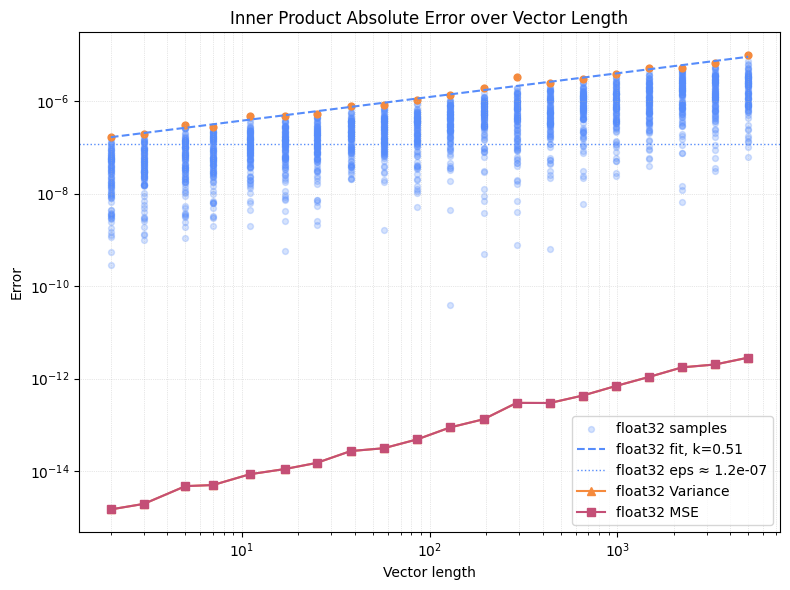

In [8]:
value_range = (0, 2)
dtype = np.float32
exp = InnerProductExperimentFMA([dtype], sizes, repeats)
exp.run()

fig, ax = plt.subplots(figsize=(8, 6))
error_matrix = np.array(exp.results[dtype])  # shape: [repeats, len(sizes)]
plot_error_vs_size(
    sizes=sizes,
    error_matrix=error_matrix,
    dtype=dtype,
    label=dtype.__name__,
    ax=ax
)
var_matrix = np.var(error_matrix, axis=0)
mse_matrix = np.mean((error_matrix - np.mean(error_matrix, axis=0)) ** 2, axis=0)
ax.loglog(sizes, var_matrix, label=f"{dtype.__name__} Variance", marker='^')
ax.loglog(sizes, mse_matrix, label=f"{dtype.__name__} MSE", marker='s')
ax.set_title("Inner Product Absolute Error over Vector Length")
ax.legend()
plt.tight_layout()
plt.show()


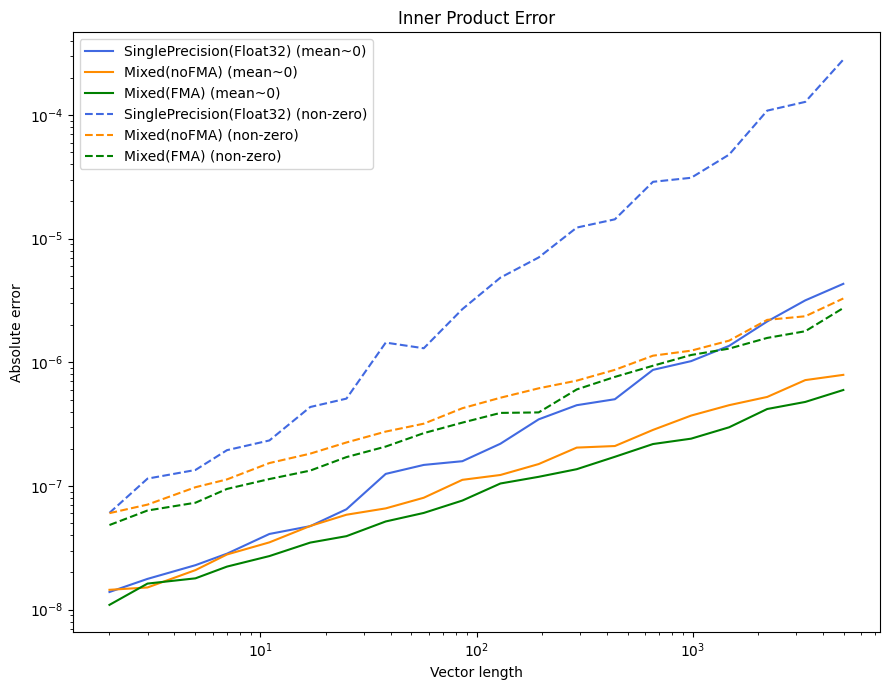

In [9]:
dtype_list = [np.float32, np.float64]
sizes = [int(1.5 ** i) for i in range(2, 22)]
repeats = 100


def run_and_collect(ExperimentClass, value_range):
    exp = ExperimentClass(dtype_list, sizes, repeats, value_range)
    exp.run()

    results = {}
    for dtype in dtype_list:
        error_matrix = np.array(exp.results[dtype])  # shape: (repeats, len(sizes))
        mean_error = np.mean(error_matrix, axis=0)
        results[dtype] = mean_error
    return results


value_range_zero = (-1, 1)
single_zero = run_and_collect(InnerProductExperiment, value_range_zero, )
mixed_zero = run_and_collect(InnerProductExperimentMixed, value_range_zero, )
fma_zero = run_and_collect(InnerProductExperimentFMA, value_range_zero, )

value_range_nonzero = (0, 2)
single_nonzero = run_and_collect(InnerProductExperiment, value_range_nonzero, )
mixed_nonzero = run_and_collect(InnerProductExperimentMixed, value_range_nonzero, )
fma_nonzero = run_and_collect(InnerProductExperimentFMA, value_range_nonzero, )

fig, ax = plt.subplots(figsize=(9, 7))

ax.loglog(sizes, single_zero[dtype], linestyle='-', label="SinglePrecision(Float32) (mean~0)", color="royalblue")
ax.loglog(sizes, mixed_zero[dtype], linestyle='-', label="Mixed(noFMA) (mean~0)", color="darkorange")
ax.loglog(sizes, fma_zero[dtype], linestyle='-', label="Mixed(FMA) (mean~0)", color="green")

ax.loglog(sizes, single_nonzero[dtype], linestyle='--', label="SinglePrecision(Float32) (non-zero)", color="royalblue")
ax.loglog(sizes, mixed_nonzero[dtype], linestyle='--', label="Mixed(noFMA) (non-zero)", color="darkorange")
ax.loglog(sizes, fma_nonzero[dtype], linestyle='--', label="Mixed(FMA) (non-zero)", color="green")

ax.set_title("Inner Product Error")
ax.set_xlabel("Vector length")
ax.set_ylabel("Absolute error")
ax.legend()
plt.tight_layout()
plt.show()